# Прогнозирование цены

### Задача
Целевая переменная — `price`. У вас есть 4 атрибута, и, очевидно, мы хотим, чтобы вы построили некую модель машинного обучения, которая прогнозирует цены.

1. Проведите первоначальный анализ данных.
2. Используйте ML модель и кратко объясните свой выбор.
3. Покажите точность вашей модели и прокомментируйте результаты.
4. Представьте нам результаты и шаги, которые вы предприняли, а также некоторые критические размышления.
5. Визуализируйте на графиках точность модели, важность признаков и корреляцию признаков с ценой.  

### Описание данных
Данные представлены в файле `price_sample.csv`.

### Комментарии

Определите, обучите и оцените прогнозирующую модель, которая принимает в качестве входных данных предоставленные данные. По вашему усмотрению вы можете разделить данные на наборы для обучения, тестирования. 

Убедитесь, что решение отражает весь ваш мыслительный процесс (для каждой ячейки кода оставляйте комментарии, иначе мы не поймем, что вы хотели сделать)

### Что мы точно хотим увидеть в вашей работе?

1. **Анализ данных**: Проведение первичного анализа данных для понимания их структуры и основных характеристик. 

2. **Обработка данных**: Это критически важный шаг, который включает в себя очистку данных, обработку пропущенных значений и дубликатов.

3. **Оценка модели**: Обучение и тестирование подходящей модели и оценка ее производительности с использованием релевантных метрик.

4. **Визуализация**: Постройте графики, которые покажут точность модели, важность признаков и корреляцию признаков с ценой. 

In [22]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import seaborn as sns

In [23]:
df = pd.read_csv("price_sample.csv") 
df.head()

,para1,para2,para3,para4,price
0,1,662.0,3000.0,3.8,73.49
1,1,340.0,2760.0,9.2,300.00
2,0,16.0,2700.0,3.0,130.00
3,1,17.0,12320.0,6.4,365.00
4,1,610.0,2117.0,10.8,357.50


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10003 entries, 0 to 10002
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   para1   10003 non-null  int64  
 1   para2   9997 non-null   float64
 2   para3   10003 non-null  float64
 3   para4   9998 non-null   float64
 4   price   10003 non-null  float64
dtypes: float64(4), int64(1)
memory usage: 390.9 KB


In [25]:
df.describe()

,para1,para2,para3,para4,price
count,10003.000000,9997.000000,10003.000000,9998.000000,10003.000000
mean,1.380986,447.270681,9547.975527,8.458024,433.774924
std,3.500408,220.913801,8022.286943,4.613645,277.443154
min,0.000000,16.000000,200.000000,1.000000,50.730000
25%,1.000000,301.000000,2899.500000,4.000000,250.000000
50%,1.000000,434.000000,6446.000000,7.200000,370.000000
75%,1.000000,582.000000,15000.000000,13.600000,550.000000
max,337.000000,2554.000000,34782.000000,27.200000,5700.000000


In [26]:
df.isnull().sum()

para1    0
para2    6
para3    0
para4    5
price    0
dtype: int64

In [27]:
df = df.drop_duplicates()          
df = df.fillna(df.median(numeric_only=True))  

In [28]:
df.isnull().sum()

para1    0
para2    0
para3    0
para4    0
price    0
dtype: int64

In [20]:
X = df.drop(columns=["price"])
y = df["price"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression().fit(X_train, y_train)
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"MSE: {mse:.2f}")
print(f"R²:  {r2:.4f}")

MSE: 41063.00
R²:  0.5432


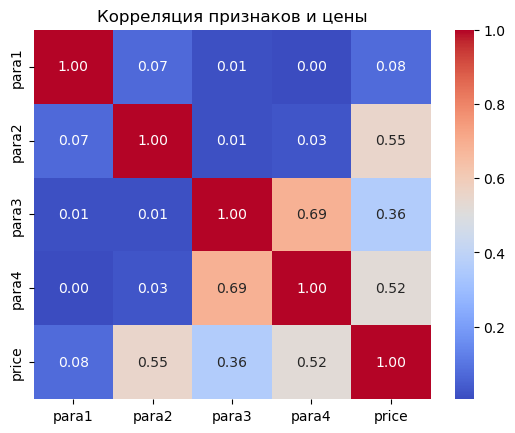

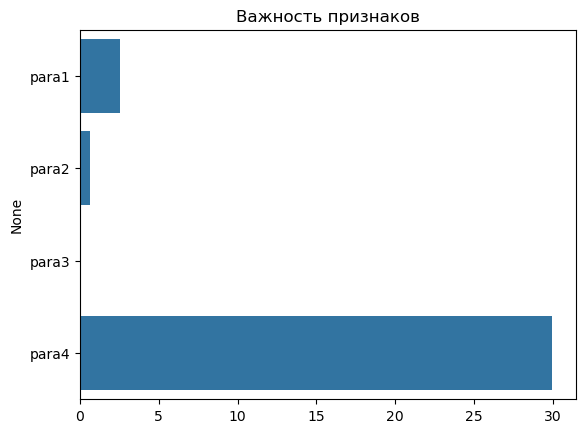

In [21]:
plt.figure()
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Корреляция признаков и цены")
plt.show()

coef = pd.Series(model.coef_, index=X.columns)
plt.figure()
sns.barplot(x=coef.values, y=coef.index)
plt.title("Важность признаков")
plt.show()